# Домашка

## Иморт модулей

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as functional
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torch import nn


## Работа с Данными

Cкачиваем датасет MNIST

In [2]:
mnistDataSet = datasets.MNIST(root='data', download = True)

Посмоторим на распределение

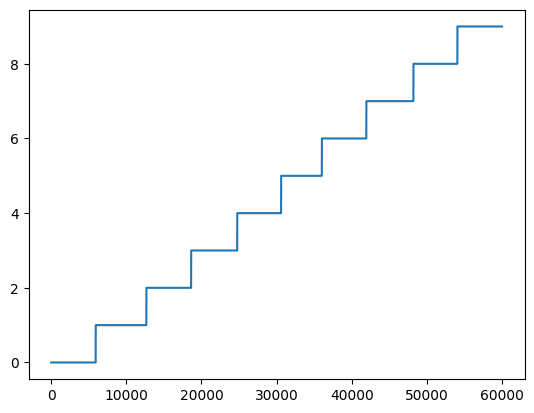

In [3]:
a = mnistDataSet.targets.numpy()
a = np.sort(a)

plt.plot(a)
plt.show()

Оно равномерное, по этому удалять ничего не нужно

Данные в исходном виде не подходят, потому что
1) фича объекта представлена в виде двумерного массива, однако можно обойтись одномерным, т.к в конечном итоге из за структуры нейросети (каждый нейрон следующего слоя связан с каждым этого) "упорядоченность данных" теряется
2) это задача классификации, а таргеты представлены одним числом, т.е таргеты можно в конечном счете отранжировать (9 > 5 > 1 > 0), это плохо, т.к в контексте задачи, весь набор данных рвнправен. Кроме того, прежде чем выдать число, модели все равно (в лучшем случае) придется сопоставить некоторый набор неотранжированых данных исходным, а после отранжировать их функцией активации на нейроне последнего слоя. Мы можем попросить модель сразу выдавать данные, которые априори нельзя отранжировать, т.е есть смысл применить к таргетам one_hot_encoding

In [4]:
class transformed_mnist(Dataset):
    def __init__(self) -> None:
        super().__init__()
        self.data = torch.flatten(mnistDataSet.data, 1)
        self.targets = torch.nn.functional.one_hot(mnistDataSet.targets, 10)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.data[index], self.targets[index]
    
    def __str__(self) -> str:
        return str(self.data)   

In [5]:
#mnistDataSet.ToTensor()

mnistDataSet[0]

(<PIL.Image.Image image mode=L size=28x28>, 5)

In [6]:
from torch.utils.data import TensorDataset, random_split


train = datasets.MNIST('./train', True, transforms.Compose([
    transforms.ToTensor()
]), download=True)

test = datasets.MNIST('./test', False, transforms.Compose([
    transforms.ToTensor(),
]), download=True)

In [7]:
class transfromed_data_set(Dataset):
    def __init__(self, data, targets) -> None:
        super().__init__()
        self.data = torch.flatten(data, 1)/255
        self.targets = torch.nn.functional.one_hot(targets, 10).float()
    
    def __getitem__(self, index):
        return self.data[index], self.targets[index]
    
    def __len__(self):
        return len(self.data)

train = transfromed_data_set(train.data, train.targets) 
test = transfromed_data_set(test.data, test.targets)


In [8]:
train_loader = DataLoader(train, 100, True)
test_loader = DataLoader(test, 100, False)

## Нейросети

In [9]:
def get_params(model):
    params_count = 0
    for param in model.parameters():
        params_count += torch.numel(param)
    params_count

def fit(model:torch.nn.Module, optimizer:torch.optim.Optimizer, train_data, loss_funciton):

    total_loss = 0

    model.train(True)
    tp = 0
    fp = 0
    tn = 0
    fn = 0

    for X, y in train_data:
        v = model(X)
        loss = loss_funciton(v, y)
        tp += np.sum((v.detach().numpy()) * (y.detach().numpy()))
        fp += np.sum((v.detach().numpy()) * (1 - y.detach().numpy()))
        tn += np.sum((1 - v.detach().numpy()) * (1 - y.detach().numpy()))
        fn += np.sum((1 - v.detach().numpy()) * (y.detach().numpy()))
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    model.train(False)

    D = {
        'accur': (tp + tn)/(tp + tn + fn + tn),
        'prec': (tp)/(tp + fp),
        'recall': tp/(tp + fn),
    }
    if D['prec'] + D['recall'] != 0:
        D['fscore'] = D['prec']*D['recall']/(D['prec'] + D['recall'])
    else:
        D['fscore'] = 0
    return total_loss/len(train_data), D




def test(model, test_data, loss_funciton):

    total_loss = 0

    tp = 0
    fp = 0
    tn = 0
    fn = 0


    for X, y in test_data:
        v = model(X)

        loss = loss_funciton(v, y)

        total_loss += loss.item()
        tp += np.sum((v.detach().numpy()) * (y.detach().numpy()))
        fp += np.sum((v.detach().numpy()) * (1 - y.detach().numpy()))
        tn += np.sum((1 - v.detach().numpy()) * (1 - y.detach().numpy()))
        fn += np.sum((1 - v.detach().numpy()) * (y.detach().numpy()))

    D = {
        'accur': (tp + tn)/(tp + tn + fn + tn),
        'prec': (tp)/(tp + fp),
        'recall': tp/(tp + fn),
    }

    if D['prec'] + D['recall'] != 0 :
        D['fscore'] = D['prec']*D['recall']/(D['prec'] + D['recall'])
    else:
        D['fscore'] = 0


    return total_loss/len(test_data), D

In [10]:
def run(model, optimizer, loss_function, train_data, test_data, ENUM = 100):
    H = []
    H1 = []

    accur1  = []
    prec1   = []
    recall1 = []
    fscore1 = []

    accur2 = []
    prec2  = []
    recall2 = []
    fscore2 = []


    for _ in range(ENUM):
        q1, D1 = fit(model, optimizer, train_data, loss_function)
        q2, D2 = test(model, test_data, loss_function)
        H.append(q1)
        H1.append(q2)
        accur1.append(D1['accur'])
        prec1.append(D1['prec'])
        recall1.append(D1['recall'])
        fscore1.append(D1['fscore'])
        accur2.append(D2['accur'])
        prec2.append(D2['prec'])
        recall2.append(D2['recall'])
        fscore2.append(D2['fscore'])


    print("обучение")
    plt.plot(H, label='train loss')
    plt.show()
    plt.plot(accur1 , label = 'accur1 ')
    plt.plot(prec1  , label = 'prec1  ')
    plt.plot(recall1, label = 'recall1')
    plt.plot(fscore1, label = 'fscore1')
    plt.legend()
    plt.show()

    print("тестирование")
    plt.plot(H1, label = 'test loss')
    plt.show()
    plt.plot(accur2 , label = 'accur2 ')
    plt.plot(prec2  , label = 'prec2  ')
    plt.plot(recall2, label = 'recall2')
    plt.plot(fscore2, label = 'fscore2')
    plt.legend()
    plt.show()

### Первый вариант

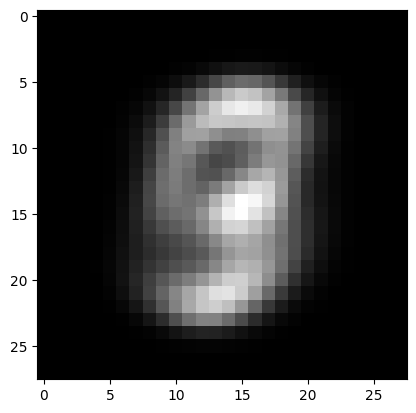

In [11]:
D = np.sum(mnistDataSet.data.numpy()/255, 0)/6000
plt.imshow(D**2, cmap='gray')

Видно, что есть около 8 основных структур (3 ярких белых пятна, 3 серых
    (соединяют яркие) и 2 черных)

Т.к каждый нейрон 1 скрытого слоя должен отражать именно отдельную структуру (в сути своей мы ищем скалярное произведение весов и входных данных, т.е смотрим на сколько данные совпадают с "памятью" модели), то будет разумно на первом скрытом слое сделать именно около 8 - 10 нейронов.
    Однако 10 нейронов как раз даст нам информацию о каждой цифре, т.е первый вариант архетектуры - однослойная нейронная сеть


In [12]:
loss_function = nn.MSELoss()

model1 = nn.Sequential(
    nn.Linear(28*28, 10),
    nn.Sigmoid()
)

optimizer1 = torch.optim.SGD(model1.parameters(), lr=1e-1)

обучение


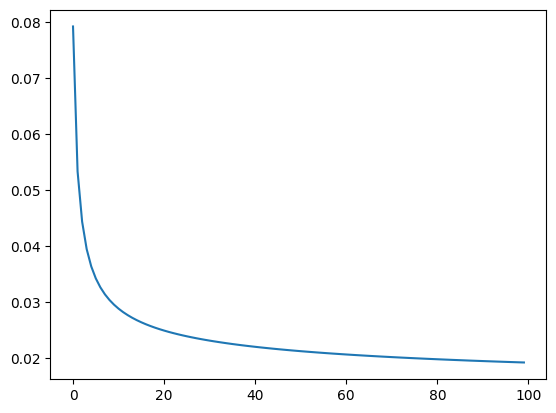

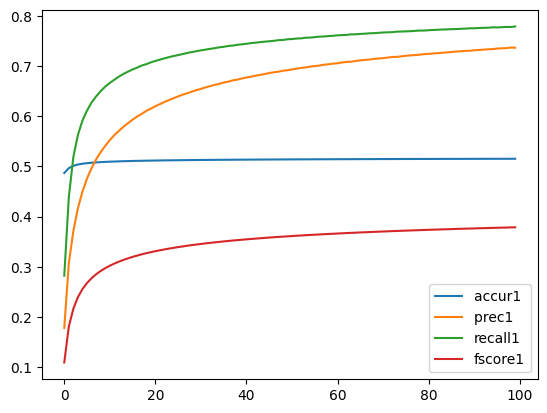

тестирование


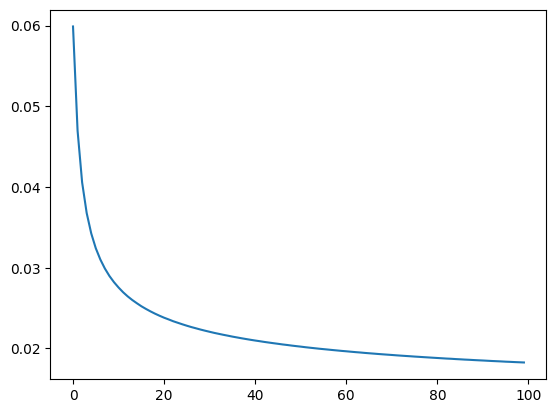

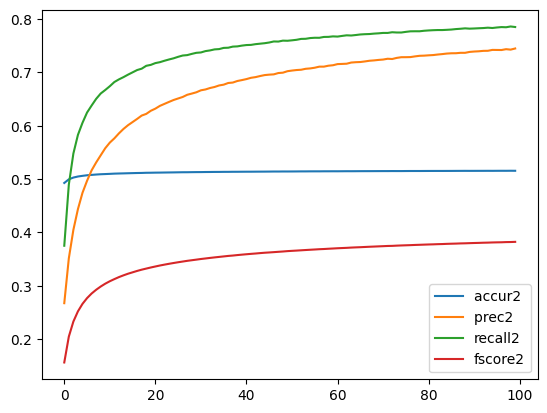

In [13]:
run(model1, optimizer1, loss_function, train_loader, test_loader)

In [14]:
# summary
get_params(model1)

### Второй Вариант

Т.к нейросеть способоно воспроизводить для фичей базовые логические опреации, то количество нейронов на каждом слое разумно выбирать исходя из количества общих структур у каждой цифры. Попытаемся это оценить :

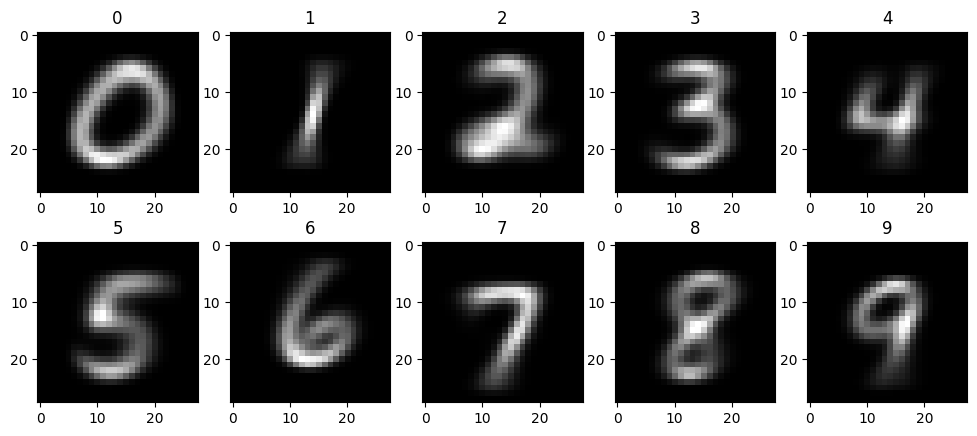

In [15]:
MN = []
plt.figure(figsize=(12,5))


for i in range(10):
    idx = mnistDataSet.targets == i
    plt.subplot(2, 5, i + 1)
    plt.title(f'{i}')
    D = mnistDataSet.data[idx].numpy()
    D = np.sum(D/255, 0)/len(D)
    plt.imshow(D**2, cmap='gray')
    MN.append(D)

plt.show()


* выше среднее по каждой цифре из датасета (MN)

In [16]:
def get_intersept(MN, show = True):
    if show:
        fig, ax = plt.subplots(len(MN), len(MN), figsize = (10, 10))

    Q = []

    for x in range(len(MN)):
        O = []
        for y in range(len(MN)):
            if show:
                if y == 0:
                    ax[x][y].set_title(x)
                if x == 0:
                    ax[x][y].set_title(y)

            v = (MN[x] * MN[y])**0.5
            if show:
                ax[x][y].imshow(v, cmap='gray')
                ax[x][y].contour(v**5)
                ax[x][y].axis('off')

            O.append(v)
        Q.append(O)

    if show:
        plt.show()
    return Q


def get_intersept_unic(MN, show = True):
    if show:
        fig, ax = plt.subplots(len(MN), len(MN), figsize = (10, 10))

    Q = []

    for x in range(len(MN)):
        O = []
        for y in range(len(MN)):
            if show:
                if y == 0:
                    ax[x][y].set_title(x)
                if x == 0:
                    ax[x][y].set_title(y)

            v = MN[x] - (MN[x] * MN[y])**0.5
            if show:
                ax[x][y].imshow(v, cmap='gray')
                ax[x][y].contour(v**5)
                ax[x][y].axis('off')

            O.append(v)
        Q.append(O)

    if show:
        plt.show()
    return Q


def get_unic_intersept(Q):
    fig, ax = plt.subplots(1, len(Q), figsize = (10, 10))
    A = []
    for x in range(len(Q)):
        k = 1
        for y in range(len(Q)):
            if x != y:
                k *= Q[x][y]
        v = k**(1/len(Q))
        v = v - np.min(v)
        v /= np.max(v)
        ax[x].set_title(x)
        ax[x].imshow(v**5, cmap='gray')
        ax[x].contour(v**5)
        ax[x].axis('off')
        A.append(v)


    plt.show()
    return A


def get_unic(MN, Q):
    fig, ax = plt.subplots(1, len(MN), figsize = (10, 10))
    A = []
    for x in range(len(MN)):
        k = 1
        for y in range(len(MN)):
            if x != y:
                k *= Q[x][y]
        v = (MN[x] - k**0.1)
        v = v - np.min(v)
        v /= np.max(v)
        ax[x].set_title(x)
        ax[x].imshow(v**5, cmap='gray')
        ax[x].contour(v**5)
        ax[x].axis('off')
        A.append(v)


    plt.show()
    return A


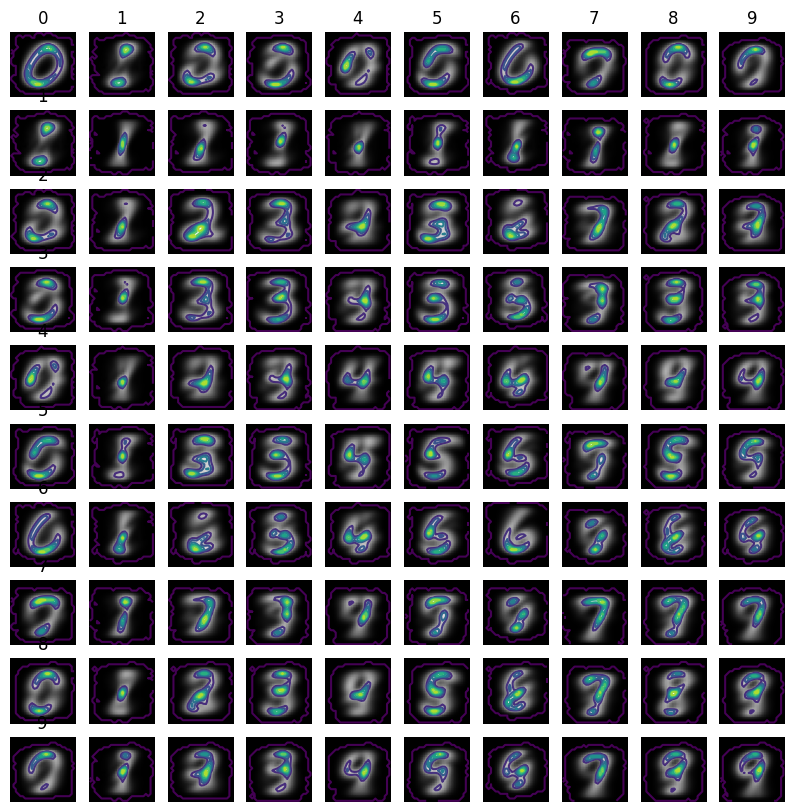

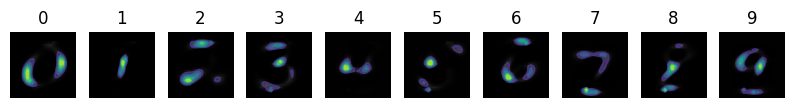

In [17]:
Q = get_intersept(MN)
A = get_unic(MN, Q)

1 таблица показывает, что общего между каждой из цифр

2 таблица показывает чем точно, каждая цифра отличается от других

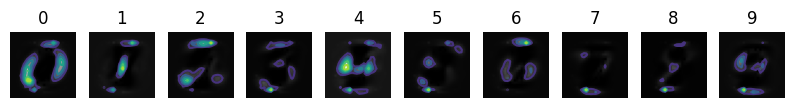

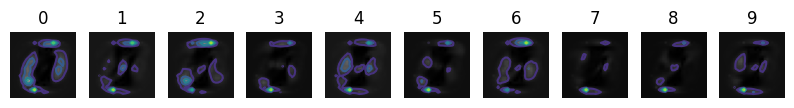

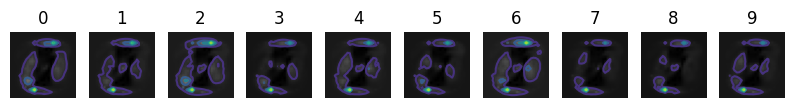

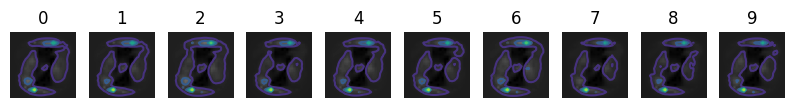

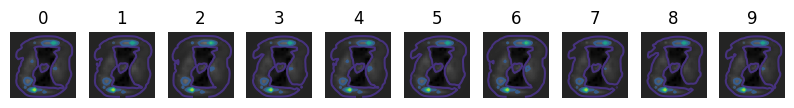

In [18]:
H = []

for _ in range(5):
    Q = get_intersept(A, False)
    A = get_unic_intersept(Q) # чем каждая "уникальность" похожа на другие "уникальности"

    K = 1
    for j in A:
        K *= j
    H.append(K**(1/len(A)))

Применяя те же алгоритмы итеративно, можно получить ряды изображений, косвенно отражающие структуру изображений (т.к мы пытаемся своего рода найти общее у общего, так нужно продолжать до тех пор, пока не появится единая структура)

Видно, что общие структуры, специфичные для каждой отдельной цифры, сливаются в более общие. По их количеству на каждой итерации можно примерно оценить количество нейронов на каждом слое
В целом можно заметить, что очень часто выделяются линии сверху, снизу и по краям, а так же точка в центре, точки по краям, так же почти всегда есть потемнения сверху и снизу (всего 9). Более общие структуры состоят из 2 уголков 2 темных пятен и точки в центре (всего 5). Ну и самое общее у всех изображений, это округлость, образованная уголками, округлость в центре и 2 темных пятна (в целом ее можно не учитывать, т.к она уже слишком не информативна). В итоге получаем, что достаточно около 2 скрытых слоев, с количеством нейронов в каждом [9, 14]

кроме того, можно заметить, что в целом у каждой цифры присутствует 2 пятна - сверху и снизу, тут явно нужно применять BatchNormalization

In [19]:
model2 = nn.Sequential(
    nn.Linear(28*28, 9),
    nn.RReLU(),
    nn.Dropout(0.4),

    nn.Linear(9, 14),
    nn.RReLU(),
    nn.Dropout(0.4),
    nn.Linear(14, 10),
    nn.Sigmoid() 
)        

optimizer2 = torch.optim.SGD(model2.parameters(), lr=1e-1)

обучение


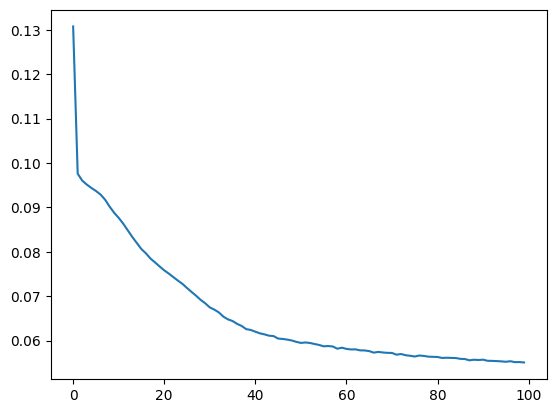

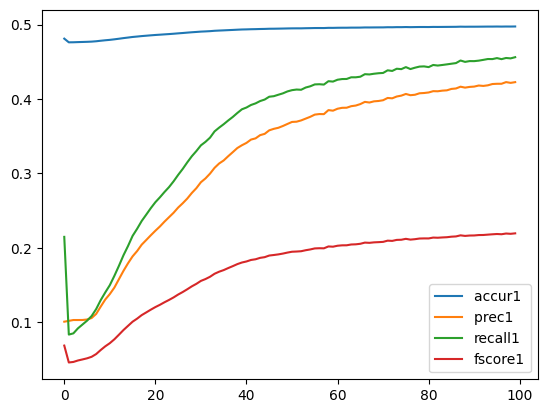

тестирование


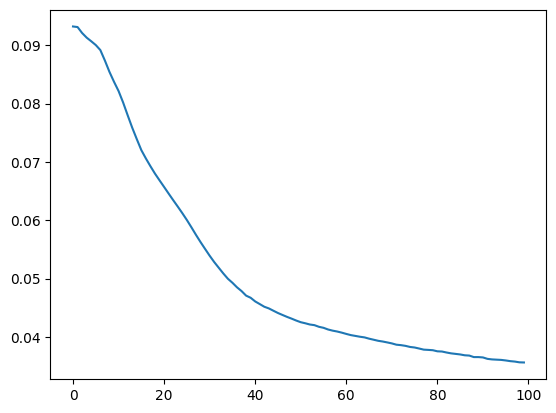

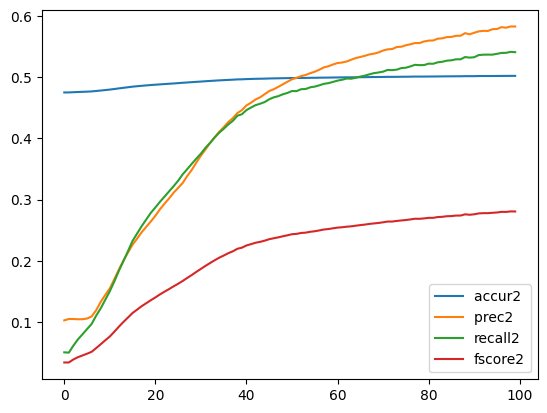

In [20]:
run(model2, optimizer2, loss_function, train_loader, test_loader)

In [21]:
# summary
get_params(model2)

### Расширение второго

т.к цифры на картинке могут быть смещены влего или в право, то не будет лишним умножить количетсов нейронов в каждом скрытом слое на 3 (центр, лево, право)

In [22]:

model2_1 = nn.Sequential(
    nn.Linear(28*28, 14*3),
    nn.RReLU(),
    nn.Dropout(0.3),
    nn.Linear(14*3, 9*3),
    nn.RReLU(),
    nn.Dropout(0.3),
    nn.Linear(9*3, 10),
    nn.Sigmoid()
)        

optimizer2_1 = torch.optim.SGD(model2_1.parameters(), lr=1e-1)

обучение


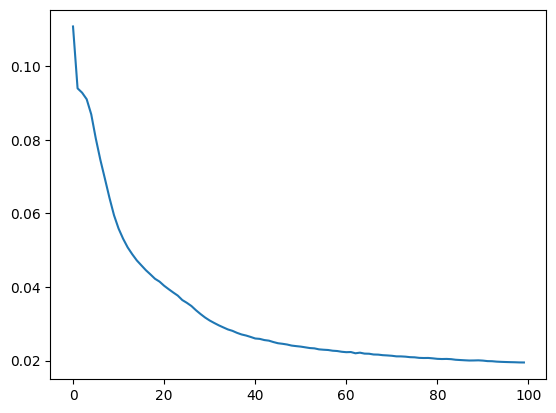

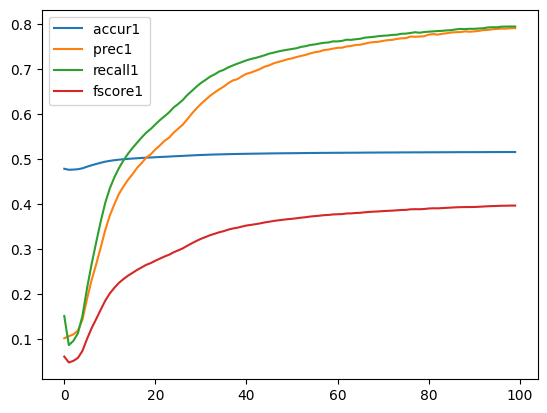

тестирование


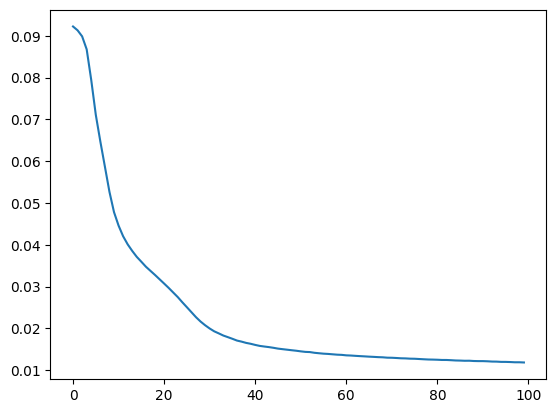

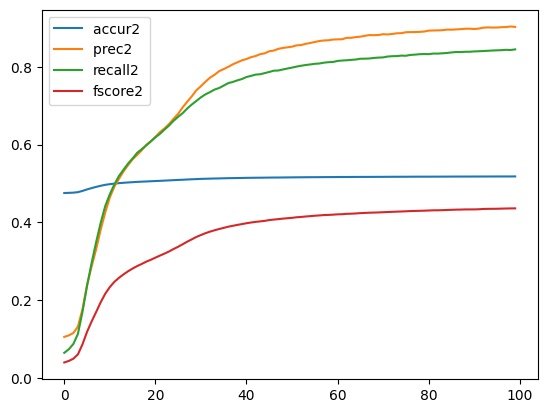

In [23]:
run(model2_1, optimizer2_1, loss_function, train_loader, test_loader)

In [24]:
# summary
get_params(model2_1)

### Третий Вариант

In [25]:

model3 = nn.Sequential(
    nn.Linear(28*28, 64),
    nn.RReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 32),
    nn.RReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 10),
    nn.Sigmoid()
)

optimizer3 = torch.optim.SGD(model3.parameters(), lr=1e-1)

обучение


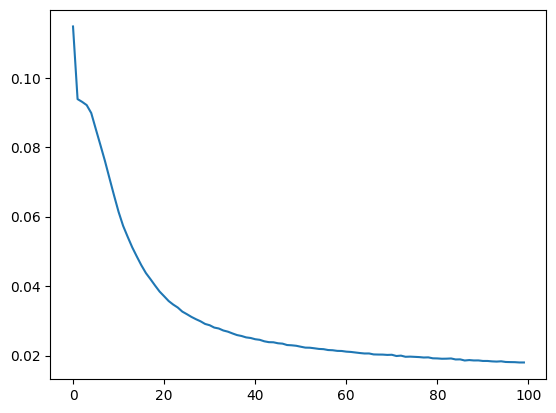

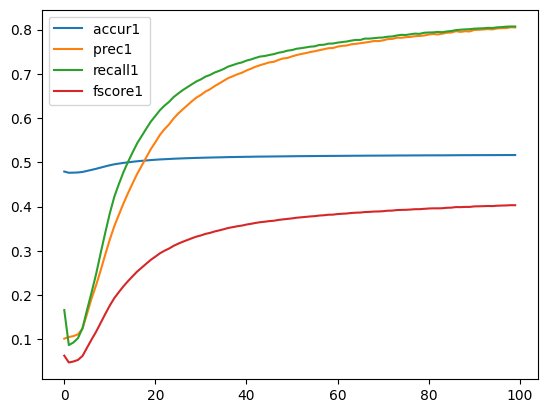

тестирование


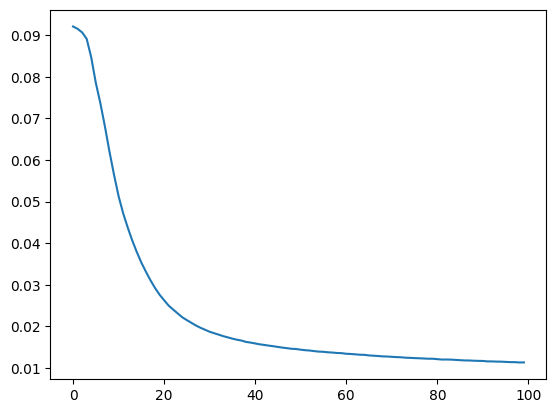

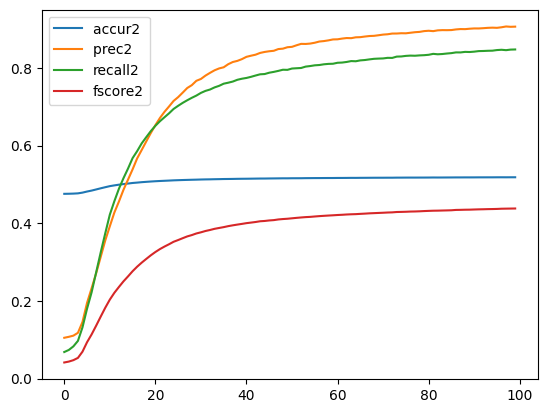

In [26]:
run(model3, optimizer3, loss_function, train_loader, test_loader)

In [27]:
# summary
get_params(model3)

|модель(номер)|мин ошибка| accuracy| precision| recall | f-score|
|-------------|----------|---------|----------|--------|--------|
|1            | 0.02     |    0.5  |  0.8     |    0.8 |   0.37 |
|-------------|----------|---------|----------|--------|--------|
|2            |  0.045   |   0.5   |   0.6    |    0.5 |    0.3 |
|-------------|----------|---------|----------|--------|--------|
|2.1          |  0.01    |0.5      |   0.9    |     0.8|    0.4 |
|-------------|----------|---------|----------|--------|--------|
|3            |  0.15    |   0.5   |   0.9    |    0.78|    0.4 |

Я думаю что 2 последнии модели лучше всего справляются со своей задачей, т.к у них достаточное количество как нейронов, так и слоев. Однако 2.1 справляется лучше, возможно это везение, а возможно это из за того, что количество ее слоев было ыбрано с учетом анализа данных


К сожалениию я не разобрался как работает batchNorm1d, где именно его размещать, у меня возникает ошибка при попытке его использовать, по этому я решил его неиспользовать и так многое пришлось изучить самостоятельно. Разобратся уже не успеваю, да и устал от этого я тоже.

In [72]:
from PIL import Image


def custom(model, path):
    q = Image.open(path, 'r')
    gray = q.convert('L')

    i = np.asarray(gray)
    i = i.reshape((28**2))
    u = torch.Tensor(i/255)
    P = model(u).detach().numpy()
    P -= np.min(P)
    P/= np.max(P)
    P = np.round(P*100)

    for i, n in enumerate(P):
        print(f'{i}  -   {n}%')

In [75]:
#custom(model3, './my_pic/my_pic.png')

0  -   1.0%
1  -   0.0%
2  -   100.0%
3  -   56.0%
4  -   0.0%
5  -   2.0%
6  -   16.0%
7  -   0.0%
8  -   0.0%
9  -   0.0%


*Ляшенков Илья*